# EDA - Extended Yale B

Notebook nay xem truc tiep raw `CroppedYale` de kiem tra phan bo anh, do sang toi va cac truong hop anh gan nhu den hoan toan. Notebook khong rebuild dataset.


In [1]:
from pathlib import Path
import re
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image


In [2]:
config = {
    "raw_dir": PROJECT_ROOT / "data" / "raw" / "CroppedYale",
    "sample_subject": "yaleB01",
    "dark_thresholds": [10, 20, 30, 40, 50, 60, 80, 100],
    "grid_examples": 10,
    "run_detector_probe": False,
}

pd.Series({k: str(v) if isinstance(v, Path) else v for k, v in config.items()})


raw_dir               d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
sample_subject                                                  yaleB01
dark_thresholds                       [10, 20, 30, 40, 50, 60, 80, 100]
grid_examples                                                        10
run_detector_probe                                                False
dtype: object

In [3]:
PATTERN = re.compile(r"(?P<subject>yaleB\d+)_(?P<pose>P\d{2})(?:A(?P<azimuth>[+-]\d{3})E(?P<elevation>[+-]\d{2})|_(?P<ambient>Ambient))")


def parse_yale_name(path: Path) -> dict:
    match = PATTERN.search(path.stem)
    if match is None:
        return {
            "subject": path.parent.name,
            "pose": None,
            "azimuth": None,
            "elevation": None,
            "is_ambient": "Ambient" in path.stem,
        }
    groups = match.groupdict()
    return {
        "subject": groups["subject"],
        "pose": groups["pose"],
        "azimuth": None if groups["azimuth"] is None else int(groups["azimuth"]),
        "elevation": None if groups["elevation"] is None else int(groups["elevation"]),
        "is_ambient": groups["ambient"] is not None,
    }


def load_gray_array(path: Path) -> np.ndarray:
    with Image.open(path) as image:
        return np.asarray(image, dtype=np.float32)


def show_image_grid(paths, title: str, n_cols: int = 5, figsize=(14, 8)):
    paths = list(paths)
    if not paths:
        print(f"No images for: {title}")
        return
    n_cols = min(n_cols, len(paths))
    n_rows = int(np.ceil(len(paths) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.atleast_1d(axes).reshape(n_rows, n_cols)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, path in zip(axes.ravel(), paths):
        ax.imshow(load_gray_array(Path(path)), cmap="gray")
        ax.set_title(Path(path).stem, fontsize=8)
        ax.axis("off")
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()


In [4]:
raw_dir = Path(config["raw_dir"])
image_paths = sorted(raw_dir.glob("yaleB*/*.pgm"))

rows = []
for path in image_paths:
    info = parse_yale_name(path)
    image = load_gray_array(path)
    rows.append({
        "path": str(path),
        "file_name": path.name,
        "subject": info["subject"],
        "pose": info["pose"],
        "azimuth": info["azimuth"],
        "elevation": info["elevation"],
        "is_ambient": info["is_ambient"],
        "height": int(image.shape[0]),
        "width": int(image.shape[1]),
        "pixel_mean": float(image.mean()),
        "pixel_std": float(image.std()),
        "pixel_min": float(image.min()),
        "pixel_max": float(image.max()),
    })

df = pd.DataFrame(rows)
summary = pd.Series({
    "total_images": int(len(df)),
    "total_subjects": int(df["subject"].nunique()),
    "ambient_images": int(df["is_ambient"].sum()),
    "non_ambient_images": int((~df["is_ambient"]).sum()),
    "mean_pixel_mean": float(df["pixel_mean"].mean()),
    "median_pixel_mean": float(df["pixel_mean"].median()),
    "min_pixel_mean": float(df["pixel_mean"].min()),
    "max_pixel_mean": float(df["pixel_mean"].max()),
})
display(summary)
display(df.head())


total_images          2452.000000
total_subjects          38.000000
ambient_images          38.000000
non_ambient_images    2414.000000
mean_pixel_mean         68.644748
median_pixel_mean       68.995182
min_pixel_mean           0.103175
max_pixel_mean         186.714752
dtype: float64

,path,file_name,subject,pose,azimuth,elevation,is_ambient,height,width,pixel_mean,pixel_std,pixel_min,pixel_max
0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...,yaleB01_P00_Ambient.pgm,yaleB01,P00,NaN,NaN,True,192,168,1.195064,1.528161,0.0,11.0
1,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...,yaleB01_P00A+000E+00.pgm,yaleB01,P00,0.0,0.0,False,192,168,114.591362,35.453293,9.0,246.0
2,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...,yaleB01_P00A+000E+20.pgm,yaleB01,P00,0.0,20.0,False,192,168,116.482544,46.327545,3.0,254.0
3,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...,yaleB01_P00A+000E+45.pgm,yaleB01,P00,0.0,45.0,False,192,168,106.804840,60.740105,2.0,255.0
4,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...,yaleB01_P00A+000E+90.pgm,yaleB01,P00,0.0,90.0,False,192,168,15.720889,28.754875,0.0,255.0


## Brightness Distribution


count    38.000000
mean     64.526316
std       1.224454
min      60.000000
25%      65.000000
50%      65.000000
75%      65.000000
max      65.000000
Name: count, dtype: float64

,threshold,count,ratio
0,10,89,0.036297
1,20,235,0.095840
2,30,403,0.164356
3,40,563,0.229608
4,50,761,0.310359
5,60,1010,0.411909
6,80,1496,0.610114
7,100,1988,0.810767


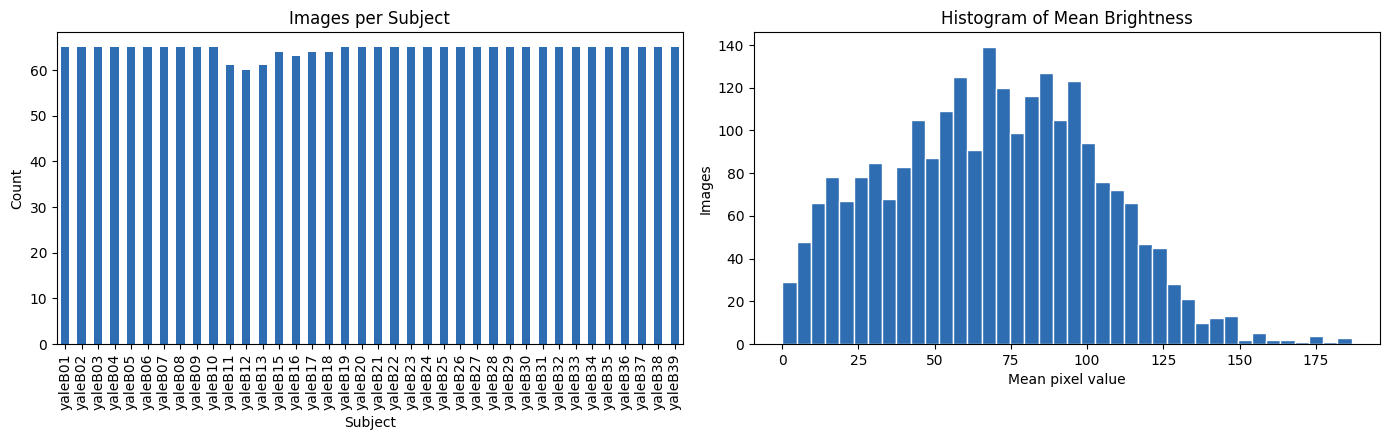

In [5]:
subject_counts = df["subject"].value_counts().sort_index()
display(subject_counts.describe())

dark_threshold_df = pd.DataFrame({
    "threshold": config["dark_thresholds"],
    "count": [int((df["pixel_mean"] <= t).sum()) for t in config["dark_thresholds"]],
})
dark_threshold_df["ratio"] = dark_threshold_df["count"] / len(df)
display(dark_threshold_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
subject_counts.plot(kind="bar", ax=axes[0], color="#2f6db2")
axes[0].set_title("Images per Subject")
axes[0].set_xlabel("Subject")
axes[0].set_ylabel("Count")

axes[1].hist(df["pixel_mean"], bins=40, color="#2f6db2", edgecolor="white")
axes[1].set_title("Histogram of Mean Brightness")
axes[1].set_xlabel("Mean pixel value")
axes[1].set_ylabel("Images")
fig.tight_layout()


,file_name,subject,pixel_mean,pixel_max,path
2286,yaleB37_P00A+095E+00.pgm,yaleB37,0.103175,3.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
2156,yaleB35_P00A+095E+00.pgm,yaleB35,0.119792,4.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
2091,yaleB34_P00A+095E+00.pgm,yaleB34,0.238250,5.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
2351,yaleB38_P00A+095E+00.pgm,yaleB38,0.344370,6.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
2221,yaleB36_P00A+095E+00.pgm,yaleB36,0.350353,6.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
455,yaleB08_P00_Ambient.pgm,yaleB08,0.516896,7.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
2416,yaleB39_P00A+095E+00.pgm,yaleB39,0.552083,6.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
94,yaleB02_P00A+095E+00.pgm,yaleB02,0.998636,6.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
65,yaleB02_P00_Ambient.pgm,yaleB02,1.031653,6.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
130,yaleB03_P00_Ambient.pgm,yaleB03,1.074095,35.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...


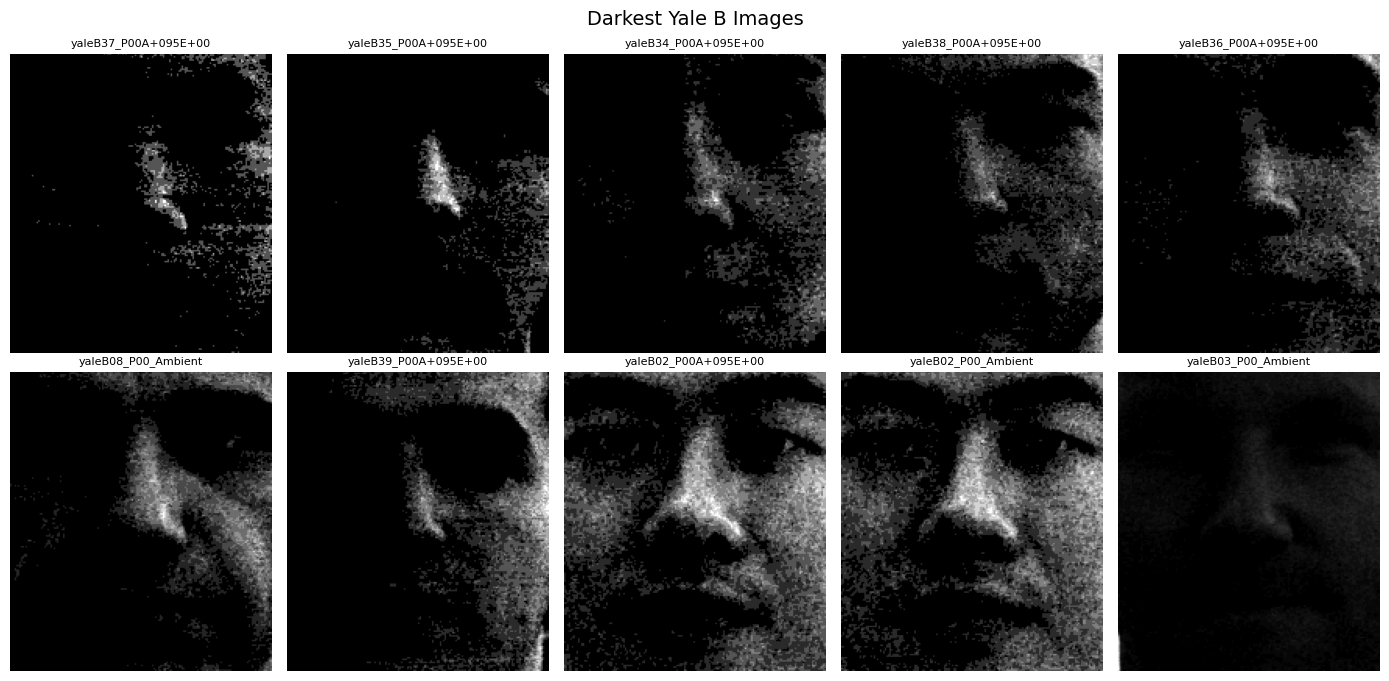

In [6]:
display(df.nsmallest(config["grid_examples"], "pixel_mean")[["file_name", "subject", "pixel_mean", "pixel_max", "path"]])
show_image_grid(
    df.nsmallest(config["grid_examples"], "pixel_mean")["path"],
    title="Darkest Yale B Images",
    n_cols=5,
    figsize=(14, 7),
)


,file_name,subject,pixel_mean,pixel_max,path
780,yaleB13_P00A+010E+00.pgm,yaleB13,186.714752,255.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
778,yaleB13_P00A+005E+10.pgm,yaleB13,183.502884,255.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
809,yaleB13_P00A-015E+20.pgm,yaleB13,182.822800,255.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
810,yaleB13_P00A-020E+10.pgm,yaleB13,181.377792,255.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
773,yaleB13_P00A+000E+20.pgm,yaleB13,177.101105,255.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
782,yaleB13_P00A+015E+20.pgm,yaleB13,173.935791,255.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
806,yaleB13_P00A-005E-10.pgm,yaleB13,173.799011,255.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
807,yaleB13_P00A-010E+00.pgm,yaleB13,172.736923,255.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
772,yaleB13_P00A+000E+00.pgm,yaleB13,172.613647,255.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...
779,yaleB13_P00A+005E-10.pgm,yaleB13,164.105255,255.0,d:\HCMUTE_project\Math_for_ML\math_for_ml\data...


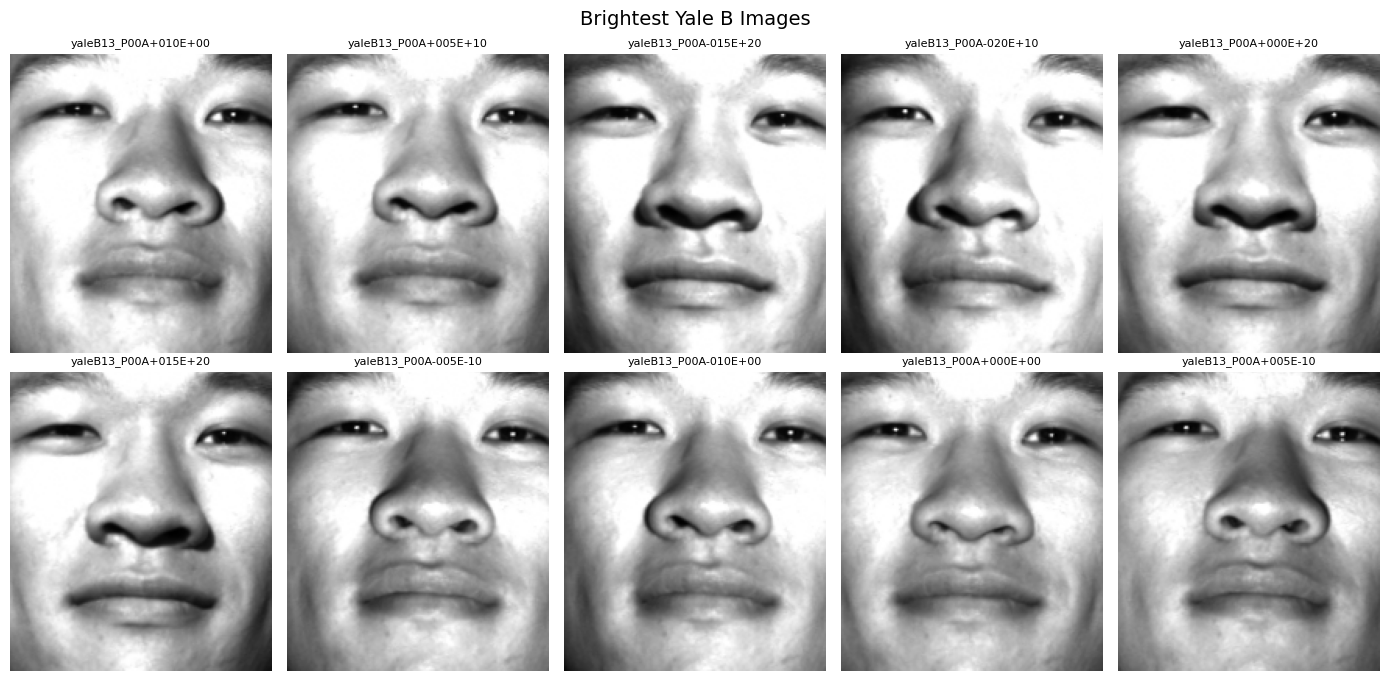

In [7]:
display(df.nlargest(config["grid_examples"], "pixel_mean")[["file_name", "subject", "pixel_mean", "pixel_max", "path"]])
show_image_grid(
    df.nlargest(config["grid_examples"], "pixel_mean")["path"],
    title="Brightest Yale B Images",
    n_cols=5,
    figsize=(14, 7),
)


,file_name,pixel_mean,azimuth,elevation,is_ambient
0,yaleB01_P00_Ambient.pgm,1.195064,NaN,NaN,True
64,yaleB01_P00A-130E+20.pgm,14.735522,-130.0,20.0,False
4,yaleB01_P00A+000E+90.pgm,15.720889,0.0,90.0,False
32,yaleB01_P00A+110E+65.pgm,16.667442,110.0,65.0,False
35,yaleB01_P00A+130E+20.pgm,16.674294,130.0,20.0,False
63,yaleB01_P00A-120E+00.pgm,20.380611,-120.0,0.0,False
34,yaleB01_P00A+120E+00.pgm,20.854631,120.0,0.0,False
61,yaleB01_P00A-110E+65.pgm,21.522879,-110.0,65.0,False
31,yaleB01_P00A+110E+40.pgm,29.076668,110.0,40.0,False
62,yaleB01_P00A-110E-20.pgm,29.788876,-110.0,-20.0,False


,file_name,pixel_mean,azimuth,elevation,is_ambient
3,yaleB01_P00A+000E+45.pgm,106.804840,0.0,45.0,False
12,yaleB01_P00A+020E+10.pgm,108.891151,20.0,10.0,False
45,yaleB01_P00A-035E+15.pgm,109.122086,-35.0,15.0,False
42,yaleB01_P00A-020E-10.pgm,111.232918,-20.0,-10.0,False
1,yaleB01_P00A+000E+00.pgm,114.591362,0.0,0.0,False
44,yaleB01_P00A-025E+00.pgm,114.751488,-25.0,0.0,False
8,yaleB01_P00A+005E-10.pgm,115.425842,5.0,-10.0,False
11,yaleB01_P00A+015E+20.pgm,115.470085,15.0,20.0,False
2,yaleB01_P00A+000E+20.pgm,116.482544,0.0,20.0,False
38,yaleB01_P00A-010E+00.pgm,118.198906,-10.0,0.0,False


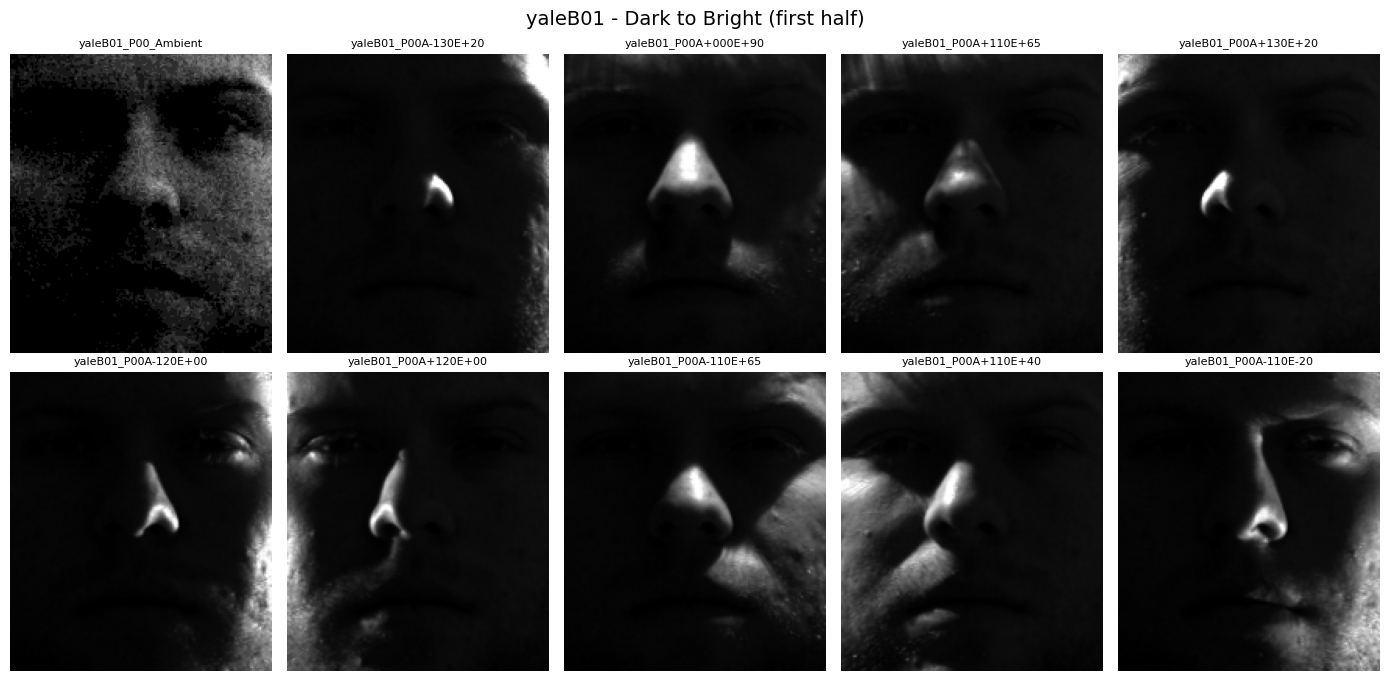

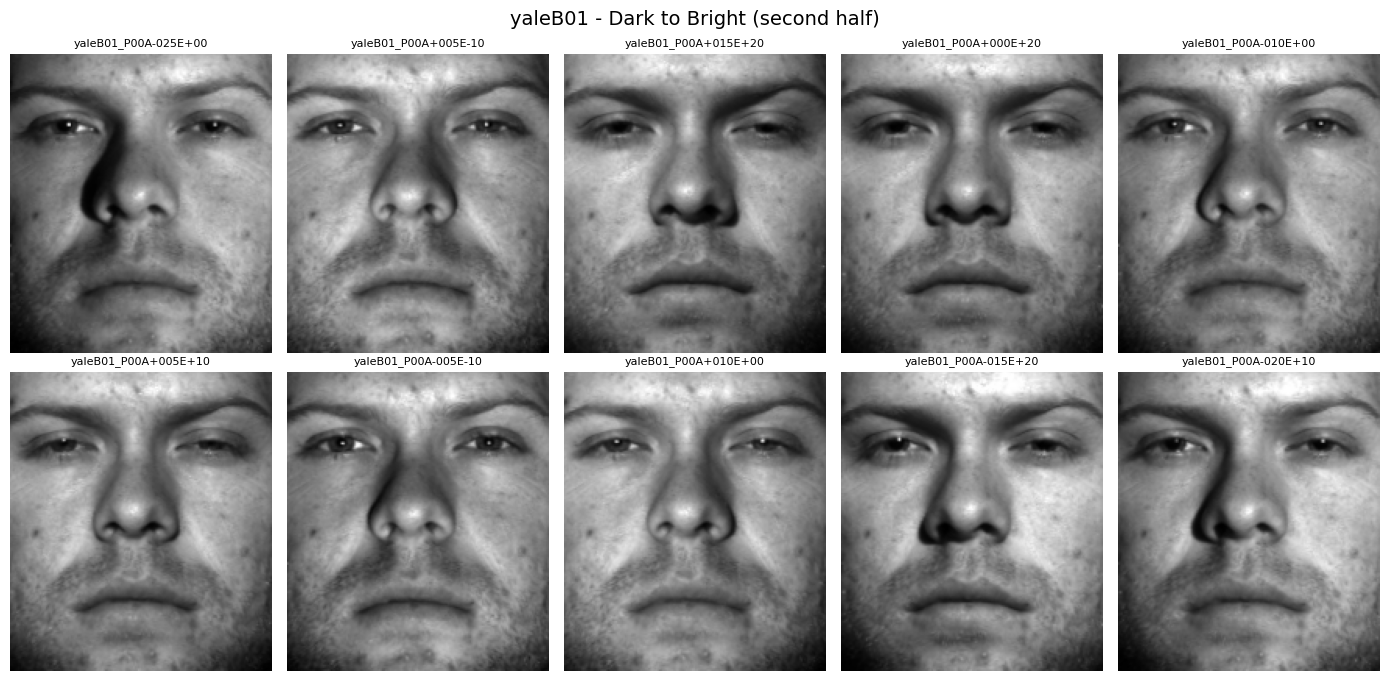

In [8]:
subject_df = df[df["subject"] == config["sample_subject"]].sort_values("pixel_mean")
display(subject_df[["file_name", "pixel_mean", "azimuth", "elevation", "is_ambient"]].head(15))
display(subject_df[["file_name", "pixel_mean", "azimuth", "elevation", "is_ambient"]].tail(15))

show_image_grid(
    subject_df.head(config["grid_examples"])["path"],
    title=f"{config['sample_subject']} - Dark to Bright (first half)",
    n_cols=5,
    figsize=(14, 7),
)
show_image_grid(
    subject_df.tail(config["grid_examples"])["path"],
    title=f"{config['sample_subject']} - Dark to Bright (second half)",
    n_cols=5,
    figsize=(14, 7),
)


## Optional Detector Probe (Slow)

Cell nay chi chay khi can kiem tra nhanh vi sao detector de fail tren Yale B. Mac dinh de `False` de notebook van chay nhanh.


In [13]:
if config["run_detector_probe"]:
    from src.process import analyze_subject_count_thresholds

    detector_probe_df = pd.DataFrame(
        analyze_subject_count_thresholds(
            "extended_yale_b",
            thresholds=[1, 5, 10, 20, 30, 40, 50],
            face_detection="mtcnn",
            min_face_area_ratio=0.08,
        )
    )
    display(detector_probe_df)
else:
    print("Detector probe skipped. Set config['run_detector_probe'] = True if needed.")


Detector probe skipped. Set config['run_detector_probe'] = True if needed.
